<a href="https://colab.research.google.com/github/DSAlexRS/curso-datos-python/blob/main/04_Datos_desde_APIs_y_librerias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. Datos en línea y primera exploración con Pandas

**Curso:** Análisis de datos para la investigación con Python

**Propósito:** Obtener datos con pocas instrucciones y convertirlos rápidamente en tablas que puedan revisarse, resumirse y graficarse.

**Ruta:** fuente en línea → DataFrame → revisión básica → pregunta exploratoria

Este cuaderno está pensado para una clase virtual demostrativa. Primero se explica la idea, luego se observa el código y, después de varios ejemplos, aparece una pausa práctica.

## Cómo trabajar en Google Colab

1. Guarda una copia del notebook en tu Drive.
2. Ejecuta en orden con el botón de reproducción o con `Shift + Enter`.
3. Una celda de texto explica y una celda de código ejecuta instrucciones.
4. Si reinicias el entorno, usa **Entorno de ejecución → Ejecutar todas**.
5. En las pausas prácticas modifica la celda marcada y luego compara con la solución.

Un error no daña el computador. Lee la última línea del mensaje y revisa nombres, mayúsculas, comillas, paréntesis e indentación.

## 1. La idea esencial

Una API permite solicitar datos a un servicio. Una librería puede simplificar la solicitud. En este curso no construiremos conexiones complejas: descargaremos una tabla, comprobaremos su estructura y empezaremos a explorarla con Pandas.

Trabajaremos con tres ejemplos:

1. Banco Mundial mediante `wbgapi`;
2. datos.gov.co mediante `requests`;
3. Yahoo Finance mediante `yfinance` como muestra breve de otra fuente.
4. Scraping ofertas inmobiliarias

In [ ]:
import sys
import subprocess
import importlib.util

# En Colab instalamos solo las librerías que todavía no estén disponibles.
for paquete in ["wbgapi", "yfinance", "bs4"]:
    if importlib.util.find_spec(paquete) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "beautifulsoup4" if paquete == "bs4" else paquete
        ])

import pandas as pd
import matplotlib.pyplot as plt
import requests
import wbgapi as wb
import yfinance as yf

print("Entorno preparado")
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import re

Entorno preparado


La celda instala únicamente los paquetes que falten. `pandas` administra tablas, `matplotlib` construye gráficos, `requests` consulta una dirección web y las otras dos librerías simplifican fuentes concretas.

## 2. Banco Mundial con una librería

Consultaremos el indicador `IT.NET.USER.ZS`: personas que usan Internet como porcentaje de la población. Solo debemos indicar países y años.

In [ ]:
codigos_paises = ["COL", "MEX", "PER", "CHL", "ARG", "BRA"]

internet_ancho = wb.data.DataFrame(
    "IT.NET.USER.ZS",
    codigos_paises,
    time=range(2019, 2025),
    labels=True
)
internet_ancho

,Country,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
economy,,,,,,,
BRA,Brazil,73.912440,81.342694,80.689893,80.527751,84.150602,84.463472
ARG,Argentina,79.946952,85.514386,87.150707,88.375357,89.228972,89.667152
CHL,Chile,85.017601,87.459297,90.232803,92.318199,94.457423,95.590243
PER,Peru,59.950504,65.251798,71.107826,74.674952,79.484845,81.957060
MEX,Mexico,69.632109,71.490175,75.626505,78.632179,81.183188,83.122338
COL,Colombia,65.006901,69.795335,73.028374,72.796379,77.336863,79.345433


Cada fila es un país y cada columna `YR...` es un año. Esta forma ancha sirve para leer una tabla, pero para agrupar y graficar suele ser más cómoda la forma larga: una fila por país-año.

In [ ]:
internet_tabla = internet_ancho.reset_index()
columnas_anio = internet_tabla.filter(like="YR").columns.tolist()

internet_largo = internet_tabla.melt(
    id_vars=["economy", "Country"],
    value_vars=columnas_anio,
    var_name="anio",
    value_name="internet"
)
internet_largo["anio"] = (
    internet_largo["anio"]
    .str.replace("YR", "", regex=False)
    .astype(int)
)
internet_largo = internet_largo.rename(
    columns={"economy": "codigo_pais", "Country": "pais"}
)
internet_largo.head(15)

,codigo_pais,pais,anio,internet
0,BRA,Brazil,2019,73.912440
1,ARG,Argentina,2019,79.946952
2,CHL,Chile,2019,85.017601
3,PER,Peru,2019,59.950504
4,MEX,Mexico,2019,69.632109
5,COL,Colombia,2019,65.006901
6,BRA,Brazil,2020,81.342694
7,ARG,Argentina,2020,85.514386
8,CHL,Chile,2020,87.459297
9,PER,Peru,2020,65.251798


`melt()` no cambia los valores: reorganiza columnas de años como filas. Ahora `pais` y `anio` identifican una observación y `internet` contiene la medida.

### Pausa práctica: reconocer la tabla

**Tiempo sugerido: 3–5 minutos.** Muestra la forma, los nombres de columnas y los tipos de `internet_largo`.

In [ ]:
# Usa shape, columns y dtypes

### Respuesta sugerida

In [ ]:
print("Forma:", internet_largo.shape)
print("Columnas:", internet_largo.columns.tolist())
print(internet_largo.dtypes)

Forma: (36, 4)
Columnas: ['codigo_pais', 'pais', 'anio', 'internet']
codigo_pais     object
pais            object
anio             int64
internet       float64
dtype: object


In [ ]:
internet_largo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   codigo_pais  36 non-null     object 
 1   pais         36 non-null     object 
 2   anio         36 non-null     int64  
 3   internet     36 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.3+ KB


## 3. Primera exploración con Pandas

Antes de una prueba estadística revisamos tamaño, faltantes, rangos y categorías.

In [ ]:
print("Países:", internet_largo["pais"].nunique())
print("Años:", sorted(internet_largo["anio"].unique()))
print("Faltantes:", internet_largo["internet"].isna().sum())

Países: 6
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Faltantes: 0


In [ ]:
internet_largo["internet"].describe().round(2)

,internet
count,36.00
mean,79.99
std,8.58
min,59.95
25%,73.69
50%,80.61
75%,85.92
max,95.59


`describe()` informa cantidad disponible, media, desviación, mínimo, cuartiles y máximo. Todavía no explica por qué existen diferencias.

In [ ]:
resumen_pais = (
    internet_largo
    .groupby("pais")
    .agg(
        promedio_internet=("internet", "mean"),
        minimo_internet=("internet", "min"),
        maximo_internet=("internet", "max")
    )
    .sort_values("promedio_internet", ascending=False)
)
resumen_pais.round(1)

,promedio_internet,minimo_internet,maximo_internet
pais,,,
Chile,90.8,85.0,95.6
Argentina,86.6,79.9,89.7
Brazil,80.8,73.9,84.5
Mexico,76.6,69.6,83.1
Colombia,72.9,65.0,79.3
Peru,72.1,60.0,82.0


Agrupar por país resume seis años. Es distinto de comparar países en un solo año. El periodo debe aparecer en la interpretación.

### Pausa práctica: filtrar una unidad

**Tiempo sugerido: 3–5 minutos.** Selecciona Colombia, ordena por año y calcula el cambio entre primera y última observación.

In [ ]:
# Crea colombia_internet y cambio_colombia

### Respuesta sugerida

In [ ]:
colombia_internet = internet_largo[internet_largo["codigo_pais"].eq("COL")].sort_values("anio")
cambio_colombia = colombia_internet["internet"].iloc[-1] - colombia_internet["internet"].iloc[0]
print(colombia_internet)
print("Cambio:", round(cambio_colombia, 2), "puntos porcentuales")

   codigo_pais      pais  anio   internet
5          COL  Colombia  2019  65.006901
11         COL  Colombia  2020  69.795335
17         COL  Colombia  2021  73.028374
23         COL  Colombia  2022  72.796379
29         COL  Colombia  2023  77.336863
35         COL  Colombia  2024  79.345433
Cambio: 14.34 puntos porcentuales


## 4. Primeras figuras

Un gráfico debe identificar variable, unidad y periodo. Cada línea representa un país; no representa individuos dentro del país.

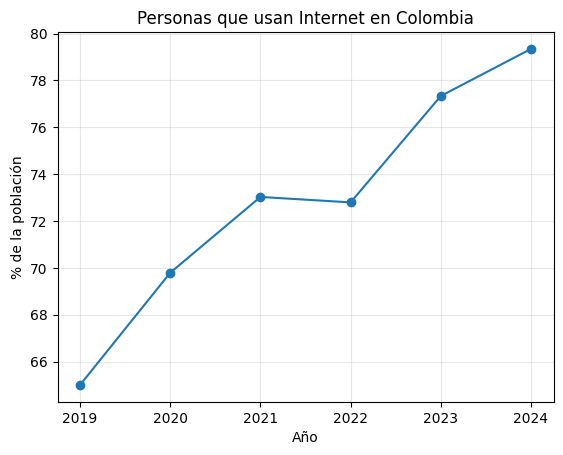

In [ ]:
# Filtramos las observaciones de Colombia y graficamos su evolución en el tiempo.
colombia = internet_largo[
    internet_largo["codigo_pais"] == "COL"
]

plt.plot(
    colombia["anio"],
    colombia["internet"],
    marker="o"
)

plt.title("Personas que usan Internet en Colombia")
plt.xlabel("Año")
plt.ylabel("% de la población")
plt.grid(alpha=0.3)
plt.show()

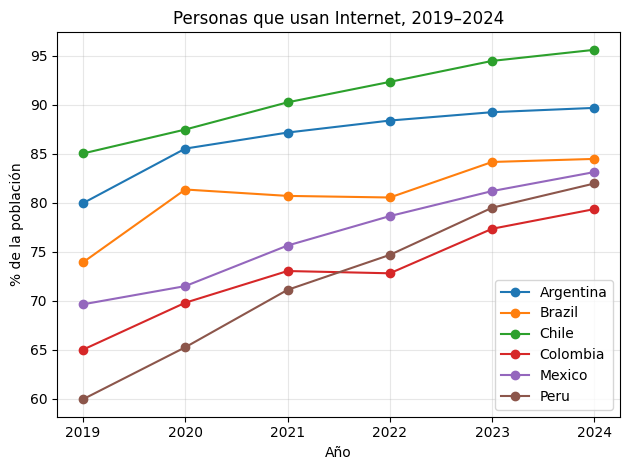

In [ ]:
# Cada grupo reúne las observaciones de un país ordenadas por año.
for codigo, grupo in internet_largo.groupby("codigo_pais"):
    plt.plot(
        grupo["anio"],
        grupo["internet"],
        marker="o",
        label=grupo["pais"].iloc[0]
    )

plt.title("Personas que usan Internet, 2019–2024")
plt.xlabel("Año")
plt.ylabel("% de la población")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

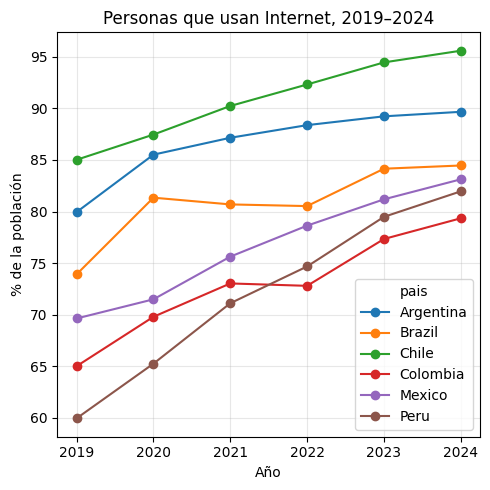

In [ ]:
# Reorganizamos los datos: cada país se convierte en una columna.
# Pandas puede graficar automáticamente una línea por cada columna.

grafico = internet_largo.pivot(
    index="anio",
    columns="pais",
    values="internet"
)

grafico.plot(
    marker="o",
    figsize=(5, 5)
)

plt.title("Personas que usan Internet, 2019–2024")
plt.xlabel("Año")
plt.ylabel("% de la población")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

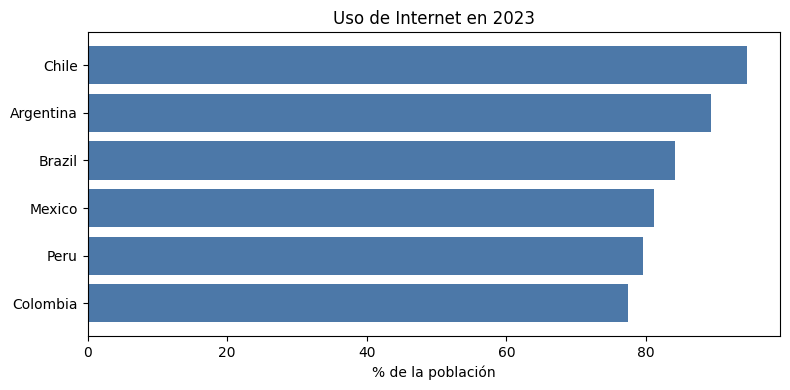

In [ ]:
internet_2023 = (
    internet_largo[internet_largo["anio"].eq(2023)]
    .sort_values("internet")
)

plt.figure(figsize=(8, 4))
plt.barh(internet_2023["pais"], internet_2023["internet"], color="#4C78A8"  ) #color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]
plt.xlabel("% de la población")
plt.title("Uso de Internet en 2023")
plt.tight_layout()
plt.show()

### Pausa práctica: formular una observación

**Tiempo sugerido: 3–5 minutos.** Identifica el valor mayor de 2023 y redacta una frase descriptiva sin lenguaje causal.

In [ ]:
fila_mayor = internet_2023.loc[internet_2023["internet"].idxmax()]
hallazgo = "Completa"
print(fila_mayor)
print(hallazgo)

codigo_pais          CHL
pais               Chile
anio                2023
internet       94.457423
Name: 26, dtype: object
Completa


### Respuesta sugerida

In [ ]:
fila_mayor = internet_2023.loc[internet_2023["internet"].idxmax()]
hallazgo = f"Entre los seis países observados, {fila_mayor['pais']} registró el mayor porcentaje de uso de Internet en 2023 ({fila_mayor['internet']:.1f}%)."
print(hallazgo)

Entre los seis países observados, Chile registró el mayor porcentaje de uso de Internet en 2023 (94.5%).


## 5. Una API directa con `requests`

Para datos.gov.co usamos una dirección y dos parámetros: un filtro y un límite. No desarrollaremos paginación en esta sesión.

In [ ]:
# URL: https://www.datos.gov.co/Vivienda-Ciudad-y-Territorio/Registro-de-transacciones-inmobiliarias-en-Colombi/7y2j-43cv/about_data

# API: https://www.datos.gov.co/api/v3/views/7y2j-43cv/query.json

url_datos_gov = "https://www.datos.gov.co/resource/7y2j-43cv.json"
parametros = {
    "$limit": 2000,
    "$where": "departamento = 'BOYACÁ'"
}

respuesta = requests.get(url_datos_gov, params=parametros, timeout=40)
print("Código HTTP:", respuesta.status_code)
respuesta.raise_for_status()

datos_gov = pd.DataFrame(respuesta.json())
datos_gov.head()

Código HTTP: 200


,pk,matricula,fecha_radica_texto,year_radica,orip,divipola,departamento,municipio,tipo_predio_zona,categoria_ruralidad_2024,...,nombre_natujur,documento_justificativo,count_a,count_de,predios_nuevos,tiene_valor,tiene_mas_de_un_valor,valor,fecha_apertura_texto,folios_derivados
0,15001-070-254569-00001-00920-2023,070-254569,2023-07-18 00:00:00,2023,70,15001,BOYACÁ,TUNJA,URBANO,Ciudades y aglomeraciones,...,LOTEO,00-ESCRITURA 926 DE 22/06/2023; 070-TUNJA,2,0,1,1,0,0.0,NaN,NaN
1,15001-070-254570-00001-00920-2023,070-254570,2023-07-18 00:00:00,2023,70,15001,BOYACÁ,TUNJA,URBANO,Ciudades y aglomeraciones,...,LOTEO,00-ESCRITURA 926 DE 22/06/2023; 070-TUNJA,2,0,1,1,0,0.0,NaN,NaN
2,15001-070-254571-00001-00920-2023,070-254571,2023-07-18 00:00:00,2023,70,15001,BOYACÁ,TUNJA,URBANO,Ciudades y aglomeraciones,...,LOTEO,00-ESCRITURA 926 DE 22/06/2023; 070-TUNJA,2,0,1,1,0,0.0,NaN,NaN
3,15001-070-254572-00001-00920-2023,070-254572,2023-07-18 00:00:00,2023,70,15001,BOYACÁ,TUNJA,URBANO,Ciudades y aglomeraciones,...,LOTEO,00-ESCRITURA 926 DE 22/06/2023; 070-TUNJA,2,0,1,1,0,0.0,NaN,NaN
4,15299-078-034199-00007-00125-2022,078-34199,23/11/22,2022,78,15299,BOYACÁ,GARAGOA,URBANO,Intermedio,...,COMPRAVENTA,00-ESCRITURA 1691 DEL 21/11/22; GARAGOA,1,1,0,1,0,5000000.0,2008-01-24 14:58:45,NaN


El código 200 indica que la solicitud fue atendida. Después convertimos la lista de registros JSON en un DataFrame. La ficha del conjunto sigue siendo necesaria para comprender cada variable.

In [ ]:
print("Forma:", datos_gov.shape)
print("Columnas:", datos_gov.columns.tolist())
print(datos_gov.dtypes.head(10))

Forma: (2000, 24)
Columnas: ['pk', 'matricula', 'fecha_radica_texto', 'year_radica', 'orip', 'divipola', 'departamento', 'municipio', 'tipo_predio_zona', 'categoria_ruralidad_2024', 'num_anotacion', 'estado_folio', 'dinamica_2024', 'cod_natujur', 'nombre_natujur', 'documento_justificativo', 'count_a', 'count_de', 'predios_nuevos', 'tiene_valor', 'tiene_mas_de_un_valor', 'valor', 'fecha_apertura_texto', 'folios_derivados']
pk                          object
matricula                   object
fecha_radica_texto          object
year_radica                 object
orip                        object
divipola                    object
departamento                object
municipio                   object
tipo_predio_zona            object
categoria_ruralidad_2024    object
dtype: object


In [ ]:
if "municipio" in datos_gov.columns:
    print(datos_gov["municipio"].value_counts().head())
else:
    print("El nombre de la columna municipio no aparece en esta respuesta.")

municipio
TUNJA           330
BELÉN           208
AQUITANIA       201
CHINAVITA       179
CHIQUINQUIRÁ    157
Name: count, dtype: int64


### Pausa práctica: cambiar una consulta

**Tiempo sugerido: 3–5 minutos.** Construye parámetros para solicitar solamente cinco registros de Boyacá. No es necesario repetir la descarga.

In [ ]:
# Crea parametros_cinco

### Respuesta sugerida

In [ ]:
parametros_cinco = {"$limit": 5, "$where": "departamento = 'BOYACÁ'"}
print(parametros_cinco)

{'$limit': 5, '$where': "departamento = 'BOYACÁ'"}


## 6. Yahoo Finance otra fuente de datos

Yahoo muestra otra estructura: una fila por fecha y columnas por activo. Solo veremos la descarga y un resumen; el análisis exploratorio continuará con datos del Banco Mundial.

In [ ]:
try:
    # Solicitamos precios ajustados de tres activos como demostración breve.
    precios = yf.download(
        ["AAPL", "MSFT", "SPY"],
        period="3mo",
        auto_adjust=True,
        progress=False,
        threads=False
    )
    # Conservamos el cierre y retiramos fechas incompletas para resumirlo.
    cierres = precios["Close"].dropna()
    print("Forma:", cierres.shape)
    display(cierres.tail())
except Exception as error:
    cierres = pd.DataFrame()
    print("Yahoo Finance no respondió:", type(error).__name__)

Forma: (65, 3)


Ticker,AAPL,MSFT,SPY
Date,,,
2026-10-01,330.320007,512.799988,763.989990
2026-10-02,333.690002,517.530029,769.640015
2026-10-05,332.890015,525.179993,774.830017
2026-10-06,333.630005,529.299988,779.090027
2026-10-07,336.670013,529.760010,777.219971


In [ ]:
if not cierres.empty:
    rendimientos = cierres.pct_change().dropna()
    display(rendimientos.describe().T[["mean", "std", "min", "max"]])
else:
    print("Se omite el resumen porque no hubo descarga.")

,mean,std,min,max
Ticker,,,,
AAPL,0.001272,0.016682,-0.073539,0.040145
MSFT,0.005376,0.024539,-0.030379,0.155067
SPY,0.000716,0.006921,-0.015387,0.018029


`pct_change()` calcula cambios relativos entre fechas consecutivas. Profundizar en estos datos exigiría conceptos de series de tiempo que quedan fuera del alcance.

In [ ]:
import yfinance as yf
import pandas as pd

# Definimos los tickers de las Big Four tecnológicas
tickers = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Google": "GOOGL",
    "Amazon": "AMZN"
}

resultados = []

for empresa, ticker in tickers.items():
    t_obj = yf.Ticker(ticker)

    try:
        # Estado de resultados (para ingresos)
        incomestmt = t_obj.financials
        # Balance general (para activos y pasivos)
        balance = t_obj.balance_sheet

        # Tomamos el año más reciente disponible en las columnas
        ultimo_anio = balance.columns[0]

        ingresos = incomestmt.loc['Total Revenue'].iloc[0] if 'Total Revenue' in incomestmt.index else None
        activos = balance.loc['Total Assets'].iloc[0] if 'Total Assets' in balance.index else None
        pasivos = balance.loc['Total Liabilities Net Minority Interest'].iloc[0] if 'Total Liabilities Net Minority Interest' in balance.index else (balance.loc['Total Liabilities'].iloc[0] if 'Total Liabilities' in balance.index else None)

        resultados.append({
            "Empresa": empresa,
            "Ticker": ticker,
            "Año Fiscal": ultimo_anio.strftime('%Y-%m-%d') if hasattr(ultimo_anio, 'strftime') else ultimo_anio,
            "Ingresos (USD)": ingresos,
            "Activos (USD)": activos,
            "Pasivos (USD)": pasivos
        })
    except Exception as e:
        print(f"No se pudieron obtener todos los datos para {empresa} ({ticker}): {e}")

# Crear DataFrame y dar formato
df_big_four = pd.DataFrame(resultados)
display(df_big_four.round(0))

,Empresa,Ticker,Año Fiscal,Ingresos (USD),Activos (USD),Pasivos (USD)
0,Apple,AAPL,2025-09-30,4.161610e+11,3.592410e+11,2.855080e+11
1,Microsoft,MSFT,2026-06-30,3.318390e+11,7.583760e+11,3.159890e+11
2,Google,GOOGL,2025-12-31,4.028360e+11,5.952810e+11,NaN
3,Amazon,AMZN,2025-12-31,7.169240e+11,8.180420e+11,4.069770e+11


## 7. Web scraping: ofertas de casas en Tunja

Una API entrega registros estructurados. Una página web entrega HTML: BeautifulSoup permite localizar sus elementos y organizar su contenido.

Consultaremos una página de resultados de Fincaraíz. Extraeremos precio, administración, habitaciones, baños, área y enlace. Son precios de oferta; la tabla no representa ventas realizadas ni todo el mercado.

In [ ]:
url_ofertas = "https://www.fincaraiz.com.co/venta/casas/tunja/boyaca"
respuesta_ofertas = requests.get(url_ofertas, headers={"User-Agent": "Mozilla/5.0"}, timeout=40)
respuesta_ofertas.raise_for_status()
sopa = BeautifulSoup(respuesta_ofertas.text, "html.parser")
anuncios = sopa.select("a.lc-data")
if not anuncios:
    raise ValueError("La respuesta no contiene las tarjetas esperadas. Revisa la página y sus selectores.")
print("Anuncios encontrados:", len(anuncios))

Anuncios encontrados: 21


### Observar una tarjeta

Los selectores identifican elementos del HTML: `p.main-price` busca el precio; `.commonExpenses`, la administración; `.lc-typologyTag__item`, las características. La ausencia de un campo se conserva como dato faltante.

In [ ]:
primero = anuncios[0]
print(primero.get_text(" ", strip=True))
print("Enlace:", urljoin(url_ofertas, primero.get("href", "")))

$ 236.000.000 + $ 150.000 admin Casa en Tunja, Boyaca 3 Habs. 1 Baño 75 m² Casa en venta en tunja Descubra su futuro hogar en Tunja, Boyacá: casas VIS de dos niveles diseñadas para ofrecer confort y funcionalidad. En el primer piso, disfrute de una espaciosa sala comedor, cocina, una alcoba versátil y un patio con la posibilidad de un futuro baño estratégicamente ubicado bajo la escalera. El segundo nivel alberga la suite principal con un elegante vestier, un práctico estudio y una alcoba adicional, complementadas por un baño completo. Esta propiedad es ideal para quienes buscan personalizar su espacio, ya que se entrega en obra gris habitable, permitiéndole imprimir su estilo único. Además, facilitamos su inversión al recibir subsidios. Una oportunidad inigualable para construir el hogar de sus sueños en una ubicación privilegiada. Contactar
Enlace: https://www.fincaraiz.com.co/casa-en-venta-en-tunja/194122560


### Extraer texto y convertir números

Separamos las funciones de lectura del recorrido de anuncios. En precios retiramos el símbolo monetario y los separadores de miles. En las características extraemos el número junto a su etiqueta.

In [ ]:
def texto_elemento(anuncio, selector):
    elemento = anuncio.select_one(selector)
    return elemento.get_text(" ", strip=True) if elemento else None

def valor_pesos(texto):
    if texto is None:
        return None
    digitos = re.sub(r"[^0-9]", "", texto)
    return int(digitos) if digitos else None

def caracteristica(anuncio, etiqueta):
    for elemento in anuncio.select(".lc-typologyTag__item"):
        texto = elemento.get_text(" ", strip=True)
        if etiqueta in texto:
            coincidencia = re.search(r"[0-9]+(?:[.,][0-9]+)?", texto)
            if coincidencia:
                return float(coincidencia.group().replace(",", "."))
    return None

In [ ]:
filas_ofertas = []
for anuncio in anuncios:
    filas_ofertas.append({
        "titulo": texto_elemento(anuncio, ".lc-title"),
        "ubicacion": texto_elemento(anuncio, ".lc-location"),
        "precio_cop": valor_pesos(texto_elemento(anuncio, ".main-price")),
        "administracion_cop": valor_pesos(texto_elemento(anuncio, ".commonExpenses")),
        "habitaciones": caracteristica(anuncio, "Habs"),
        "banos": caracteristica(anuncio, "Baños"),
        "area_m2": caracteristica(anuncio, "m²"),
        "enlace": urljoin(url_ofertas, anuncio.get("href", "")),
    })

ofertas = pd.DataFrame(filas_ofertas).drop_duplicates(subset="enlace").reset_index(drop=True)
columnas_numericas = ["precio_cop", "administracion_cop", "habitaciones", "banos", "area_m2"]
for columna in columnas_numericas:
    ofertas[columna] = pd.to_numeric(ofertas[columna], errors="coerce")
ofertas

,titulo,ubicacion,precio_cop,administracion_cop,habitaciones,banos,area_m2,enlace
0,Casa en venta en tunja,"Casa en Tunja, Boyaca",236000000,150000.0,3.0,NaN,75.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
1,"Casa en venta en las nieves, tunja","Casa en Tunja, Boyaca",500000000,NaN,6.0,4.0,180.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
2,"Casa en venta en las nieves, tunja","Casa en Tunja, Boyaca",680000000,NaN,6.0,4.0,185.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
3,Casa en venta en tunja,"Casa en Tunja, Boyaca",280000000,NaN,5.0,4.0,120.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
4,Casa en venta en san jose,"Casa en Tunja, Boyaca",500000000,NaN,3.0,4.0,94.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
5,Casa en venta en tunja,"Casa en Tunja, Boyaca",680000000,NaN,5.0,4.0,235.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
6,Casa en venta en tunja,"Casa en Tunja, Boyaca",490000000,75000.0,4.0,3.0,157.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
7,"Casa en venta en surinama, tunja","Casa en Tunja, Boyaca",350000000,NaN,4.0,3.0,150.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
8,"Casa en venta en altagracia, tunja","Casa en Tunja, Boyaca",675000000,260000.0,NaN,NaN,114.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
9,Casa en venta en tunja,"Casa en Tunja, Boyaca",650000000,NaN,3.0,3.0,147.0,https://www.fincaraiz.com.co/casa-en-venta-en-...


### Revisar y analizar la tabla

Calculamos precio por metro cuadrado cuando el área es positiva. Administración sin valor no significa administración igual a cero. El área corresponde al campo publicado y debe interpretarse según el anuncio.

In [ ]:
display(ofertas[columnas_numericas].isna().sum())
ofertas["precio_m2_cop"] = ofertas["precio_cop"] / ofertas["area_m2"].where(ofertas["area_m2"] > 0)
display(ofertas[["titulo", "precio_cop", "area_m2", "precio_m2_cop"]].sort_values("precio_m2_cop").round(0))

,0
precio_cop,0
administracion_cop,15
habitaciones,1
banos,2
area_m2,0


,titulo,precio_cop,area_m2,precio_m2_cop
14,"Casa en venta en la maria, tunja",545000000,290.0,1879310.0
16,"Casa en venta en la maria, tunja",500000000,262.0,1908397.0
15,Casa en venta en tunja,280000000,125.0,2240000.0
3,Casa en venta en tunja,280000000,120.0,2333333.0
7,"Casa en venta en surinama, tunja",350000000,150.0,2333333.0
10,Casa en venta en tunja,500000000,210.0,2380952.0
17,Casa en venta en tunja,370000000,137.0,2700730.0
1,"Casa en venta en las nieves, tunja",500000000,180.0,2777778.0
19,Casa en venta en tunja,750000000,268.0,2798507.0
5,Casa en venta en tunja,680000000,235.0,2893617.0


### Pausa práctica: seleccionar ofertas

Selecciona ofertas con precio menor o igual a 400 millones y área mayor o igual a 100 m². Ordena por precio y muestra precio, área y enlace.

In [ ]:
# Desarrolla el ejercicio aquí.

### Respuesta sugerida

In [ ]:
seleccion_ofertas = ofertas.loc[(ofertas["precio_cop"] <= 400_000_000) & (ofertas["area_m2"] >= 100), ["precio_cop", "area_m2", "enlace"]].sort_values("precio_cop")
seleccion_ofertas

,precio_cop,area_m2,enlace
3,280000000,120.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
15,280000000,125.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
7,350000000,150.0,https://www.fincaraiz.com.co/casa-en-venta-en-...
17,370000000,137.0,https://www.fincaraiz.com.co/casa-en-venta-en-...


In [ ]:
ofertas.to_csv("ofertas_casas_tunja.csv", index=False, encoding="utf-8-sig")
print("Filas exportadas:", len(ofertas))

Filas exportadas: 21


## 8. Puente hacia el EDA

Ya podemos hacer cuatro preguntas iniciales sobre una tabla descargada:

1. ¿cuántas filas, columnas y unidades contiene?;
2. ¿qué tipos y valores faltantes aparecen?;
3. ¿cuáles son los rangos y grupos principales?;
4. ¿qué patrón merece una exploración más profunda?

El notebook 5 desarrolla distribuciones, atípicos, correlaciones e hipótesis.

In [ ]:
ficha_consulta = {
    "fuente": "Banco Mundial",
    "indicador": "IT.NET.USER.ZS",
    "periodo": "2019-2024",
    "unidad_analisis": "país-año",
    "unidad_medida": "% de la población",
}
print(ficha_consulta)

{'fuente': 'Banco Mundial', 'indicador': 'IT.NET.USER.ZS', 'periodo': '2019-2024', 'unidad_analisis': 'país-año', 'unidad_medida': '% de la población'}


## Cierre

El propósito no fue dominar protocolos de API, sino comprobar que una fuente en línea termina en un DataFrame y que desde allí aplicamos la misma lógica de Pandas: observar, tipar, filtrar, agrupar, resumir y graficar.